# Notebook 04 - Risultati finali e tabella comparativa

## Scopo del notebook

E' l'**ultimo notebook** della pipeline: a training/valutazione completati,
qui carichiamo tutti i risultati salvati e li componiamo in:
1. Una **tabella comparativa** con tutte le metriche per ogni modello.
2. Un export CSV (`logs/comparison_table.csv`) usato dal report.
3. Visualizzazione delle figure principali (confusion matrix, ROC,
   reliability diagram).
4. Stampa delle metriche dettagliate.

## Input attesi

- `logs/classical_results.json` (da `train_classical.py`).
- `models/deep/test_results.json` (da `train_deep.py`).
- `models/postprocess/calibration_results.json` (da `calibrate_and_evaluate.py`).
- `models/postprocess/tta_results.json` (da `evaluate_tta.py`).
- `logs/evaluation_results.json` (da `run_full_evaluation.py`).

I file mancanti vengono gestiti gracefully (placeholder nella tabella).


In [1]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# pandas 3.0 abilita di default `future.infer_string` (backend PyArrow per le
# stringhe), che su Windows va in access violation insieme alle DLL di torch.
# Lo disabilitiamo: questo notebook non importa src.utils, dove vige lo stesso
# fix per il resto della pipeline.
try:
    pd.set_option("future.infer_string", False)
except (KeyError, ValueError):
    pass

# Robustezza: capire se il notebook gira da `notebooks/` (sviluppo locale)
# o dalla root (in CI/test).
ROOT = Path().resolve().parent if Path().resolve().name == 'notebooks' else Path().resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print('Project root:', ROOT)


Project root: C:\Users\zucco\OneDrive\Desktop\progetto cv


## 1. Caricamento dei file di risultati

Funzione helper che carica un JSON dalla root del progetto e ritorna
`None` se il file non esiste (con logging del percorso mancante).


In [2]:
def _load_json(path):
    """Carica un JSON da ROOT/path; ritorna None se non esiste."""
    p = ROOT / path
    if p.exists():
        with open(p) as f:
            return json.load(f)
    print(f'  [missing] {p}')
    return None

# Fonti di dati: classico (SVM/RF), deep raw, deep calibrato, deep TTA, full eval.
classical   = _load_json('logs/classical_results.json')
deep_raw    = _load_json('models/deep/test_results.json')
deep_cal    = _load_json('models/postprocess/calibration_results.json')
deep_tta    = _load_json('models/postprocess/tta_results.json')
eval_full   = _load_json('logs/evaluation_results.json')

# Quick check: vediamo subito quali fonti abbiamo.
print('classical:', bool(classical))
print('deep_raw: ', bool(deep_raw))
print('deep_cal: ', bool(deep_cal))
print('deep_tta: ', bool(deep_tta))
print('eval_full:', bool(eval_full))


classical: True
deep_raw:  True
deep_cal:  True
deep_tta:  True
eval_full: True


## 2. Costruzione della tabella comparativa

Una riga per modello, le colonne sono le metriche di interesse.
"-" per metriche non disponibili (es. specificita' non calcolata dai
modelli classici nel JSON storico).

Righe placeholder con `+ GPU training` indicano configurazioni che
richiedono il training completo del modello deep su GPU CUDA (in locale
via `scripts/train_deep.py` oppure su Colab via `03_train_colab.ipynb`).


In [3]:
COLS = ['Accuracy', 'Precision', 'Recall', 'Specificity', 'F1', 'AUC-ROC', 'AUC-PR', 'Brier', 'Note']

def _fmt(v):
    """Formattatore: float a 4 decimali, altri tipi come stringa."""
    return f'{v:.4f}' if isinstance(v, float) else str(v)

rows = []

# --- Modelli classici (SVM, RF) ---
if classical:
    for key, label in [('random_forest', 'Random Forest (HOG+LBP+GLCM)'),
                        ('svm',           'SVM (HOG+LBP+GLCM, PCA-200)')]:
        m = classical.get(key, {})
        rows.append({
            'Model': label,
            'Accuracy':    _fmt(m.get('accuracy',  float('nan'))),
            'Precision':   _fmt(m.get('precision', float('nan'))),
            'Recall':      _fmt(m.get('recall',    float('nan'))),
            # Specificita' non era nei JSON classici - placeholder "-".
            'Specificity': '-',
            'F1':          _fmt(m.get('f1',        float('nan'))),
            'AUC-ROC':     _fmt(m.get('roc_auc',   float('nan'))),
            'AUC-PR':      '-',
            'Brier':       '-',
            'Note':        '',
        })

# --- Modello deep (raw / calibrato / TTA) ---
def _deep_note(d):
    """Annotazione: 'smoke (N imgs)' se il training era --subset, altrimenti
    'full training' (subset=None nel test_results.json del run completo)."""
    if d and d.get('subset'):
        return f'smoke ({d["subset"]} imgs)'
    return 'full training'

if deep_raw:
    rows.append({
        'Model': 'EfficientNet-B0 (fine-tuned)',
        'Accuracy':    _fmt(deep_raw.get('test_accuracy',  float('nan'))),
        'Precision':   _fmt(deep_raw.get('test_precision', float('nan'))),
        'Recall':      _fmt(deep_raw.get('test_recall',    float('nan'))),
        'Specificity': '-',
        'F1':          _fmt(deep_raw.get('test_f1',        float('nan'))),
        'AUC-ROC':     _fmt(deep_raw.get('test_roc_auc',   float('nan'))),
        'AUC-PR':      '-',
        'Brier':       '-',
        'Note':        _deep_note(deep_raw),
    })

if deep_cal:
    cal_m = deep_cal.get('calibrated_metrics', {})
    rows.append({
        'Model': f'EfficientNet-B0 + T-scaling (T={deep_cal["temperature"]:.3f})',
        'Accuracy':    _fmt(cal_m.get('accuracy',  float('nan'))),
        'Precision':   _fmt(cal_m.get('precision', float('nan'))),
        'Recall':      _fmt(cal_m.get('recall',    float('nan'))),
        'Specificity': '-',
        'F1':          _fmt(cal_m.get('f1',        float('nan'))),
        'AUC-ROC':     _fmt(cal_m.get('roc_auc',   float('nan'))),
        'AUC-PR':      '-',
        'Brier':       '-',
        'Note':        f'thr={deep_cal["threshold"]:.3f} (sens>=0.95)',
    })

if deep_tta:
    rows.append({
        'Model': f'EfficientNet-B0 + TTA ({deep_tta.get("n_views", 5)} views)',
        'Accuracy':    _fmt(deep_tta.get('test_accuracy',  float('nan'))),
        'Precision':   _fmt(deep_tta.get('test_precision', float('nan'))),
        'Recall':      _fmt(deep_tta.get('test_recall',    float('nan'))),
        'Specificity': '-',
        'F1':          _fmt(deep_tta.get('test_f1',        float('nan'))),
        'AUC-ROC':     _fmt(deep_tta.get('test_roc_auc',   float('nan'))),
        'AUC-PR':      '-',
        'Brier':       '-',
        'Note':        'deterministic views, thr=0.50',
    })

# --- Ensemble: non eseguito (richiederebbe piu' training indipendenti) ---
# Riga mostrata per completezza, esplicitamente marcata come lavoro futuro.
rows.append({
    'Model': 'EfficientNet-B0 + Ensemble (x3)',
    **{c: '-' for c in COLS},
    'Note': 'future work',
})

df = pd.DataFrame(rows).set_index('Model')
df


,Accuracy,Precision,Recall,Specificity,F1,AUC-ROC,AUC-PR,Brier,Note
Model,,,,,,,,,
Random Forest (HOG+LBP+GLCM),0.8874,0.8967,0.8777,-,0.8871,0.9516,-,-,
"SVM (HOG+LBP+GLCM, PCA-200)",0.9625,0.9579,0.9681,-,0.9630,0.9963,-,-,
EfficientNet-B0 (fine-tuned),0.9330,0.9454,0.9202,-,0.9326,0.9812,-,-,full training
EfficientNet-B0 + T-scaling (T=1.002),0.9115,0.8974,0.9309,-,0.9138,0.9812,-,-,thr=0.358 (sens>=0.95)
EfficientNet-B0 + TTA (5 views),0.9437,0.9465,0.9415,-,0.9440,0.9895,-,-,"deterministic views, thr=0.50"
EfficientNet-B0 + Ensemble (x3),-,-,-,-,-,-,-,-,future work


## 3. Export della tabella in CSV

In [4]:
# CSV importabile nel report tecnico (`docs/technical_analysis.md`).
out_path = ROOT / 'logs' / 'comparison_table.csv'
df.to_csv(out_path)
print(f'Saved -> {out_path}')


Saved -> C:\Users\zucco\OneDrive\Desktop\progetto cv\logs\comparison_table.csv


## 4. Visualizzazione delle figure prodotte

`run_full_evaluation.py` salva le figure in `docs/figures/`. Le
visualizziamo qui per controllo finale.


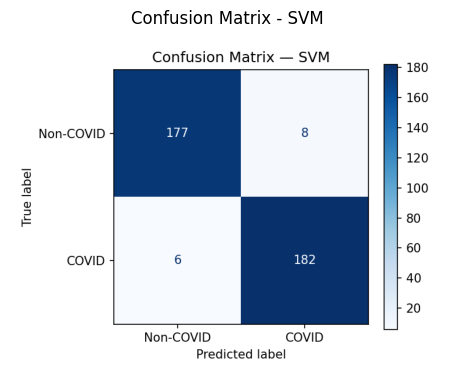

[missing] C:\Users\zucco\OneDrive\Desktop\progetto cv\docs\figures\confusion_matrix_rf.png - run scripts/run_full_evaluation.py first


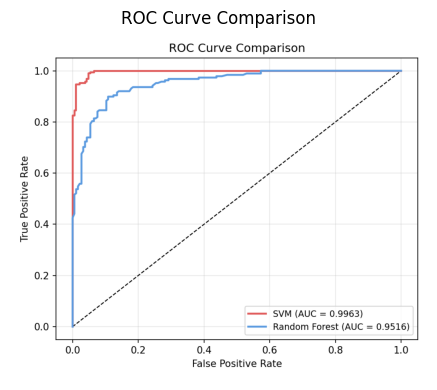

[missing] C:\Users\zucco\OneDrive\Desktop\progetto cv\docs\figures\reliability_diagram_deep.png - run scripts/run_full_evaluation.py first


In [5]:
fig_dir = ROOT / 'docs' / 'figures'

def show_figure(fname, title=''):
    """Mostra inline un PNG dalla cartella figure. Skip silent se mancante."""
    p = fig_dir / fname
    if not p.exists():
        print(f'[missing] {p} - run scripts/run_full_evaluation.py first')
        return
    img = mpimg.imread(str(p))
    plt.figure(figsize=(6, 4))
    plt.imshow(img)
    plt.axis('off')
    if title:
        plt.title(title)
    plt.tight_layout()
    plt.show()

# Le 4 figure piu' importanti del report.
show_figure('confusion_matrix_svm.png', 'Confusion Matrix - SVM')
show_figure('confusion_matrix_rf.png',  'Confusion Matrix - Random Forest')
show_figure('roc_comparison.png',       'ROC Curve Comparison')
show_figure('reliability_diagram_deep.png', 'Deep Model Reliability Diagram')


## 5. Metriche dettagliate dei modelli classici

Stampa "lunga" delle metriche da `evaluation_results.json`. Utile per
copiare valori specifici nel testo del report.


In [6]:
if eval_full:
    for model_name, metrics in eval_full.items():
        print(f'\n=== {model_name} ===')
        for k, v in metrics.items():
            # Stampiamo solo i valori float (skip i campi tipo "threshold"
            # che sono stringhe o int).
            if isinstance(v, float):
                print(f'  {k:<20} {v:.4f}')
else:
    print('Run scripts/run_full_evaluation.py to generate detailed metrics.')



=== SVM ===
  accuracy             0.9625
  precision            0.9579
  recall               0.9681
  specificity          0.9568
  f1                   0.9630
  auc_roc              0.9963
  auc_pr               0.9963
  ppv                  0.9579
  npv                  0.9672
  brier                0.0236
  ece                  0.0266

=== Random Forest ===
  accuracy             0.8874
  precision            0.8967
  recall               0.8777
  specificity          0.8973
  f1                   0.8871
  auc_roc              0.9516
  auc_pr               0.9543
  ppv                  0.8967
  npv                  0.8783
  brier                0.1027
  ece                  0.1282
